In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#Load the data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
#Target
#df["Outcome"]
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [16]:
#Dataset dimensions
df.shape
#Inspect the data types
df.info()

#basic statistics
df.describe()

#Check missing values
df.isnull().sum()

#Some medical measurements contain 0, 
#even though 0 isn't physiologically realistic for those measurements
#A zero glucose measurement in this dataset is generally treated 
#as a missing/invalid measurement not a genuine measurement of zero

(df == 0).sum() #Tell us how many zero values exist in every column

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [18]:
#Identify invalid zeros
zero_columns =[
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
(df[zero_columns] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

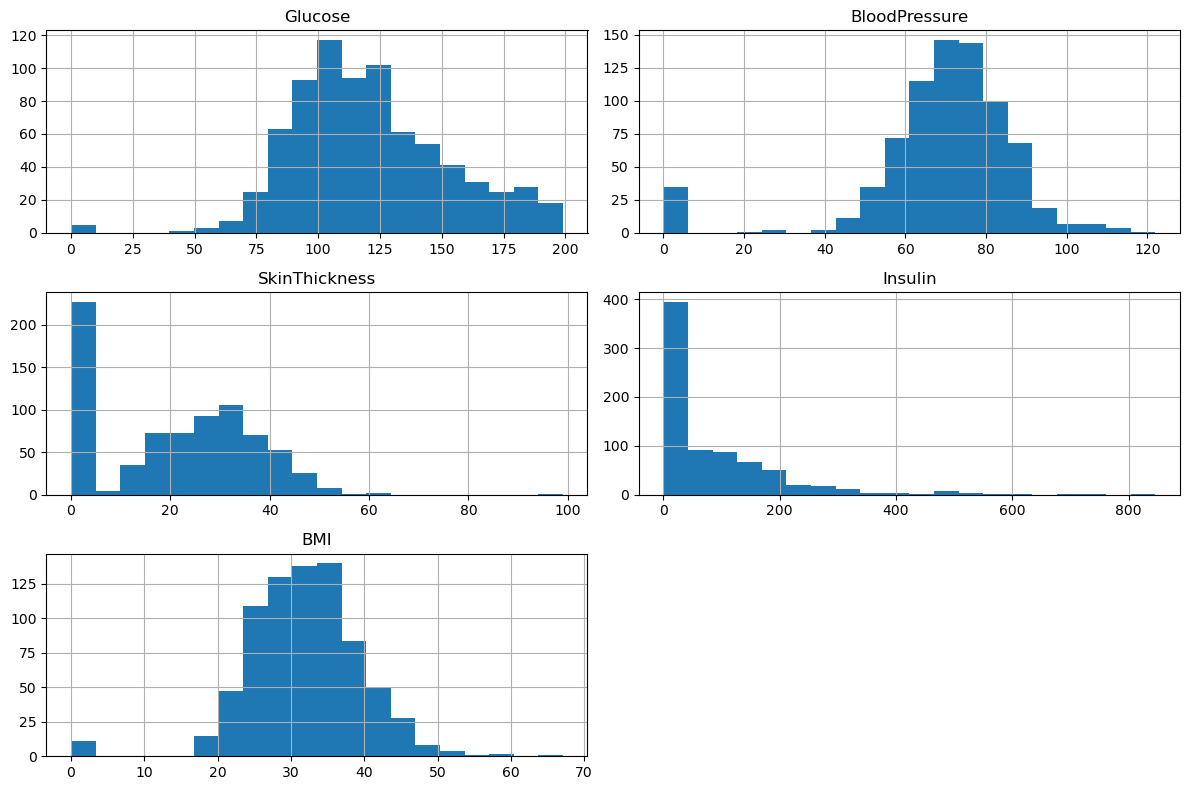

<Figure size 640x480 with 0 Axes>

In [23]:
#See the distribution first
df[zero_columns].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()
plt.savefig("../reports/distributions.png")

Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


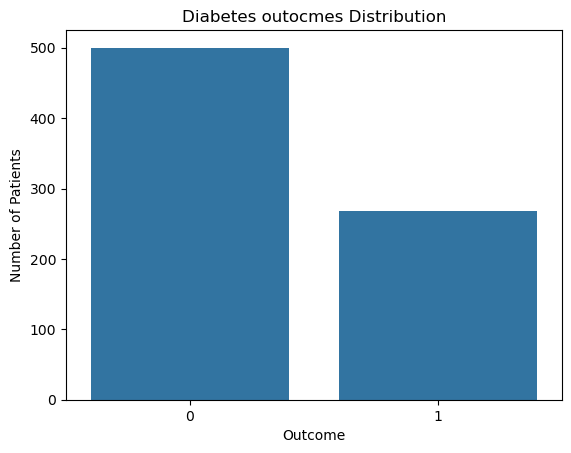

In [25]:
#Explore diabetes by outcome
#Do the feature values look different between 
#patients with and without diabetes?
sns.countplot(data = df,x="Outcome")
plt.title("Diabetes outocmes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

#Calculate percentages
outcome_counts = df["Outcome"].value_counts()

outcome_percentages = df["Outcome"].value_counts(normalize=True) * 100

print("Counts:")
print(outcome_counts)

print("\nPercentages:")
print(outcome_percentages)
plt.show()
              

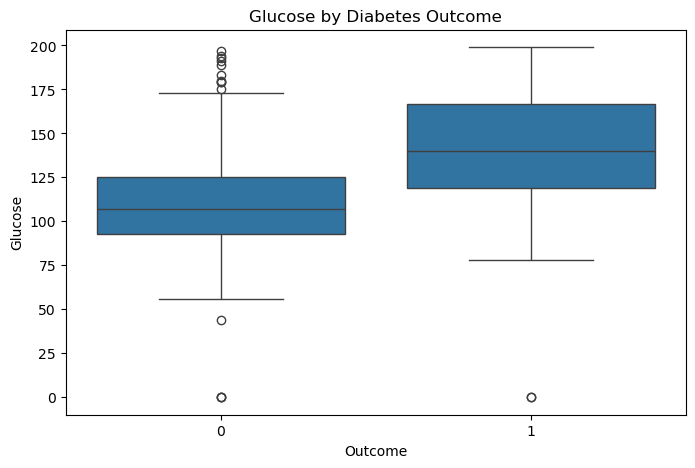

In [26]:
#Compare glucose
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Outcome", y="Glucose")

plt.title("Glucose by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")

plt.show()

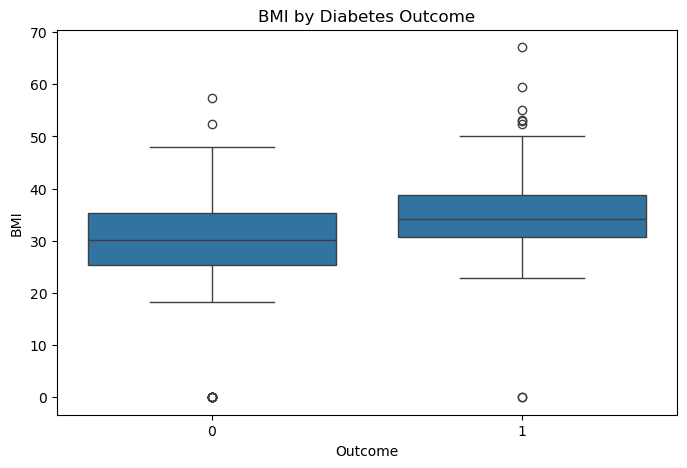

In [27]:
#Compare BMI
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Outcome", y="BMI")

plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")

plt.show()

In [ ]:
#Compare Age
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Outcome", y="Age")

plt.title("Age by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age")

plt.show()